In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neuralforecast.core import NeuralForecast
from neuralforecast.models import NHITS, NBEATS, TimesNet
from neuralforecast.losses.numpy import mae, mse

In [2]:
df = pd.read_csv(r'data/longest_patient_measurements.csv')
df['unique_id'] = 'OT'
df['y'] = df['SI']

# maxlen = 0
# for i, row in enumerate(df.iterrows()):
#     if len(row[1]) > maxlen:
#         maxlen = len(row[1])

# print(maxlen)

df['ds'] = pd.to_datetime(df['ds'])

print(df.head())

   Unnamed: 0        SI                  ds unique_id         y
0           0  0.000412 2023-01-01 00:00:00        OT  0.000412
1           1  0.000230 2023-01-01 01:00:00        OT  0.000230
2           2  0.000165 2023-01-01 02:00:00        OT  0.000165
3           3  0.000178 2023-01-01 03:00:00        OT  0.000178
4           4  0.000170 2023-01-01 04:00:00        OT  0.000170


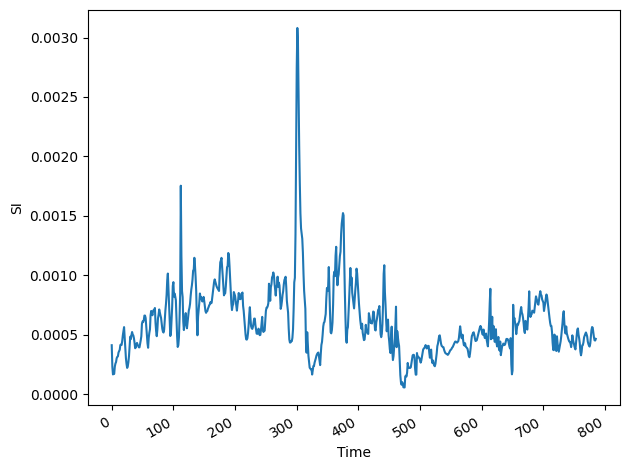

In [3]:
fig, ax = plt.subplots()

ax.plot(df['SI'])
ax.set_xlabel('Time')
ax.set_ylabel('SI')

fig.autofmt_xdate()
plt.tight_layout()
# plt.savefig("img_0.png")
plt.show()

In [4]:
horizon = 96

models = [NHITS(h=horizon,
               input_size=2*horizon,
               max_steps=50),
         NBEATS(h=horizon,
               input_size=2*horizon,
               max_steps=50),
         TimesNet(h=horizon,
                 input_size=2*horizon,
                 max_steps=50)]


nf = NeuralForecast(models=models, freq='H')
preds_df = nf.cross_validation(df=df, step_size=horizon, n_windows=2)

preds_df.head()

Seed set to 1
Seed set to 1
Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,cutoff,NHITS,NBEATS,TimesNet,Unnamed: 0,SI,y
0,OT,2023-01-25 18:00:00,2023-01-25 17:00:00,0.000967,0.009836,0.000381,594,0.000499,0.000499
1,OT,2023-01-25 19:00:00,2023-01-25 17:00:00,0.000884,0.001273,0.000357,595,0.000521,0.000521
2,OT,2023-01-25 20:00:00,2023-01-25 17:00:00,0.000599,0.001043,0.000369,596,0.000543,0.000543
3,OT,2023-01-25 21:00:00,2023-01-25 17:00:00,0.000754,-0.003545,0.000362,597,0.000561,0.000561
4,OT,2023-01-25 22:00:00,2023-01-25 17:00:00,0.000678,0.000065,0.000373,598,0.000573,0.000573


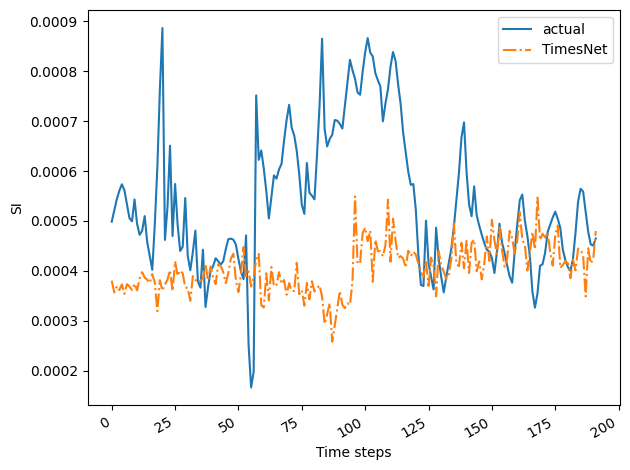

In [5]:
fig, ax = plt.subplots()

ax.plot(preds_df['SI'], label='actual')
# ax.plot(preds_df['NHITS'], label='N-HITS', ls='--')
# ax.plot(preds_df['NBEATS'], label='N-BEATS', ls=':')
ax.plot(preds_df['TimesNet'], label='TimesNet', ls='-.')

ax.legend(loc='best')
ax.set_xlabel('Time steps')
ax.set_ylabel('SI')

fig.autofmt_xdate()
# plt.ylim(-0.001, 0.001)
plt.tight_layout()
plt.savefig('out.png')

In [7]:
data = {'N-HiTS': [mae(preds_df['NHITS'], preds_df['y']), mse(preds_df['NHITS'], preds_df['y'])],
       'N-BEATS': [mae(preds_df['NBEATS'], preds_df['y']), mse(preds_df['NBEATS'], preds_df['y'])],
       'TimesNet': [mae(preds_df['TimesNet'], preds_df['y']), mse(preds_df['TimesNet'], preds_df['y'])]}

metrics_df = pd.DataFrame(data=data)
metrics_df.index = ['mae', 'mse']

metrics_df.style.highlight_min(color='lightgreen', axis=1)
metrics_df

,N-HiTS,N-BEATS,TimesNet
mae,2.840633e-04,0.002170,1.540512e-04
mse,1.308944e-07,0.000009,4.087677e-08
